## *Analisis Topik Sentimen Masyarakat terhadap Program Makan Bergizi Gratis Menggunakan BERT dan Topic Modeling*

_**Project By:**_ <br>
Nama: Johanes Cedrick Wijaya <br>
NIM: 2702213801 <br>
Jurusan: Computer Science and Mathematics <br>

===========================================================================================================================================================================================================================================================================

## A. Data Overview

### A.1. Import Data

In [ ]:
import pandas as pd

In [18]:
df = pd.read_csv('./Data/data_youtube_comments_MBG.csv')
df.head(10)

,Video_ID,User,Comment,Likes,Published_At
0,SL_PSLQXZfs,@khanzanoushin,Pemimpin yang gampang di bodohin😂😂😂,0,2026-07-16T12:02:43Z
1,SL_PSLQXZfs,@AmiruddinRA,Kalau betul diberi dengan elok bantuan makanan...,0,2026-07-16T09:45:58Z
2,SL_PSLQXZfs,@KardjoKardjo-g5v,Yo jelas kalau gak makan mati.APA KALAU GAK AD...,0,2026-07-16T04:07:01Z
3,SL_PSLQXZfs,@KardjoKardjo-g5v,MBG AJAKOK PROGRAM ANDALAN ORANGG NGARIT AJA B...,0,2026-07-16T04:05:14Z
4,SL_PSLQXZfs,@pocokia306,Coba lihat fakta dilapangan,0,2026-07-15T22:18:50Z
5,SL_PSLQXZfs,@wendiwirawan9167,"dia tuli dan keras kepala gx mau, dengar kompl...",0,2026-07-15T13:35:59Z
6,SL_PSLQXZfs,@wendiwirawan9167,ingat guys periode berikutnya jangan coblos be...,0,2026-07-15T13:35:01Z
7,SL_PSLQXZfs,@zainuddindly,MBG dipertahankan DEMI KORUPTOR DAN PENJILAT P...,0,2026-07-15T12:35:02Z
8,SL_PSLQXZfs,@zainuddindly,Yg setuju MBG itu koruptor dan penjilat semua?...,0,2026-07-15T12:33:56Z
9,SL_PSLQXZfs,@renatarenata3357,Dahulu belum ada mbg ya anak anak tidak kelap...,0,2026-07-15T08:27:40Z


### A.2. Data Info

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14578 entries, 0 to 14577
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Video_ID      14578 non-null  object
 1   User          14578 non-null  object
 2   Comment       14575 non-null  object
 3   Likes         14578 non-null  int64 
 4   Published_At  14578 non-null  object
dtypes: int64(1), object(4)
memory usage: 569.6+ KB


### A.3. Check Null Data

In [20]:
df.isnull().sum()

Video_ID        0
User            0
Comment         3
Likes           0
Published_At    0
dtype: int64

In [21]:
df[df['Comment'] == '']

,Video_ID,User,Comment,Likes,Published_At


In [22]:
df = df.dropna(subset=['Comment'])
df = df[df['Comment'] != '']

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14575 entries, 0 to 14577
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Video_ID      14575 non-null  object
 1   User          14575 non-null  object
 2   Comment       14575 non-null  object
 3   Likes         14575 non-null  int64 
 4   Published_At  14575 non-null  object
dtypes: int64(1), object(4)
memory usage: 683.2+ KB


### A.4. Check Duplicated Data

In [24]:
df.duplicated().sum()

np.int64(5)

In [25]:
df = df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14570 entries, 0 to 14577
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Video_ID      14570 non-null  object
 1   User          14570 non-null  object
 2   Comment       14570 non-null  object
 3   Likes         14570 non-null  int64 
 4   Published_At  14570 non-null  object
dtypes: int64(1), object(4)
memory usage: 683.0+ KB


===========================================================================================================================================================================================================================================================================

## B. Exploratory Data Analysis (EDA)

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "figure.facecolor": "#FFFFFF",
        "axes.facecolor": "#F8FAFC",
        "axes.edgecolor": "#E5E7EB",

        "grid.color": "#E5E7EB",
        "grid.linestyle": "--",
        "grid.linewidth": 0.7,

        "axes.labelcolor": "#334155",
        "xtick.color": "#475569",
        "ytick.color": "#475569",
        "text.color": "#334155",

        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.titlecolor": "#1E293B",

        "font.size": 11,
    }
)

sns.set_palette(
    'tab20'
)

In [28]:
df = df[['Comment']]

### B.1. Length Distribution

In [29]:
df['length'] = df['Comment'].apply(len)

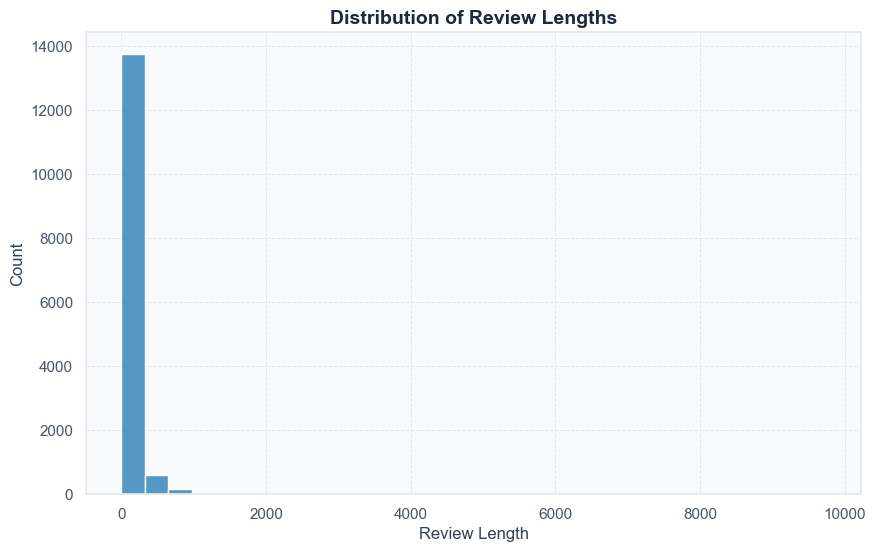

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='length', bins=30)
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length')
plt.ylabel('Count')
plt.show()

In [31]:
df['length'].describe()

count    14570.000000
mean       118.748113
std        185.877657
min          1.000000
25%         39.000000
50%         76.000000
75%        138.000000
max       9743.000000
Name: length, dtype: float64

In [32]:
df.sort_values(by='length', ascending=False).head(10)

,Comment,length
4217,*Infografis Keracunan Makanan Massal MBG yang ...,9743
4301,Assalamualaikum Warahmatullahi Wabarakatuh.\nB...,5530
10482,Surat Untuk Pak Presiden\n\nYth. Bapak Preside...,3663
348,Program Makan Bergizi Gratis (MBG) hadir denga...,3579
4353,Yg bikin anggaran dan ekonomi makin nyungsep:\...,3151
418,JIKA INGIN INDONESIA MAJU WAJIB BACA INI.\nSel...,2798
417,SETIAP NEGARA PASTI PUNYA OLIGARKINYA MASING M...,2746
14293,Dana mbg Rp15.000 per porsi dgn pembagian: Rp1...,2723
13817,1. Mengapa Uang Sekarang Bikin Rakyat Miskin\n...,2599
1164,"Yuk pak kita revisi programnya, ya memang Stun...",2470


In [33]:
df.sort_values(by='length', ascending=True).head(10)
# ini sih banyakan noisedan spam doang
# nanti cleaning

,Comment,length
11213,👍,1
5985,🥀,1
1589,h,1
7002,😢,1
2554,❤,1
3163,🔥,1
4889,y,1
8208,0,1
237,😮,1
9738,❤,1


### B.2. Word Count Distribution

In [34]:
df['word_count'] = df['Comment'].apply(lambda x: len(x.split()))

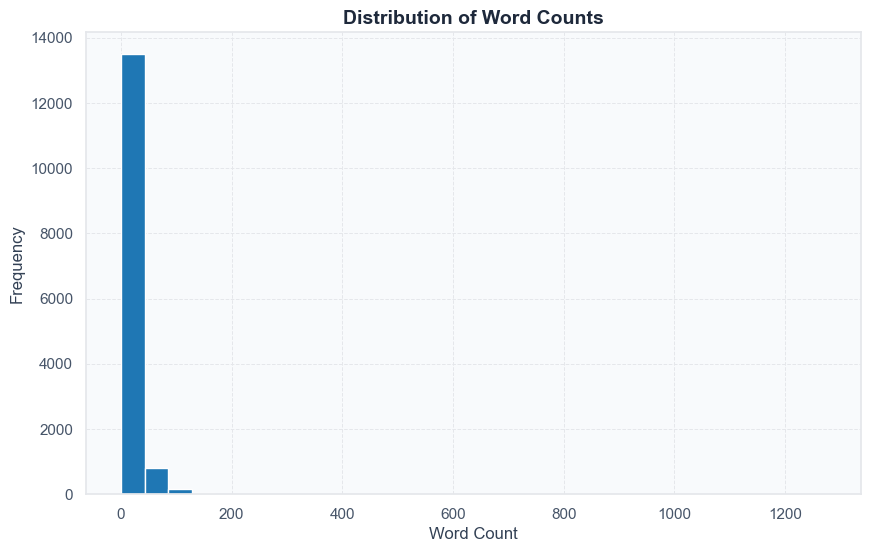

In [35]:
plt.figure(figsize=(10, 6))
plt.hist(df['word_count'], bins=30)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Distribution of Word Counts')
plt.show()

In [36]:
df['word_count'].describe()

count    14570.000000
mean        18.227454
std         26.766202
min          1.000000
25%          6.000000
50%         12.000000
75%         21.000000
max       1274.000000
Name: word_count, dtype: float64

In [37]:
df.sort_values(by='word_count', ascending=False).head(10)

,Comment,length,word_count
4217,*Infografis Keracunan Makanan Massal MBG yang ...,9743,1274
4301,Assalamualaikum Warahmatullahi Wabarakatuh.\nB...,5530,790
10482,Surat Untuk Pak Presiden\n\nYth. Bapak Preside...,3663,514
348,Program Makan Bergizi Gratis (MBG) hadir denga...,3579,485
4353,Yg bikin anggaran dan ekonomi makin nyungsep:\...,3151,484
14293,Dana mbg Rp15.000 per porsi dgn pembagian: Rp1...,2723,413
13817,1. Mengapa Uang Sekarang Bikin Rakyat Miskin\n...,2599,400
417,SETIAP NEGARA PASTI PUNYA OLIGARKINYA MASING M...,2746,362
6896,Ini saran aja nih buat Pemerintah daripada bua...,2147,355
4361,"Proyek MBG, Kopdes, konversi motor listrik, ge...",2404,338


In [38]:
df.sort_values(by='word_count', ascending=True).head(10)

,Comment,length,word_count
9548,Bagus👍,6,1
9460,setuju,6,1
9469,Setuju,6,1
9497,👍🏻👍🏻👍🏻👍🏻,8,1
9499,Betul,5,1
9503,Setujuuuuu....,14,1
9504,Setujuuuuuuuuuuu,16,1
9527,Setujuuuuuu,11,1
9556,Mantap,6,1
6554,Astaghfirullah,14,1


In [39]:
df[df['word_count'] > 2].sort_values(by='word_count', ascending=True).head(10)
# mulai dari jumlah kata 3 mulai ada makna walau singkat banget
# kita akan mulai dari word count 3 dulu

,Comment,length,word_count
7674,Tksh ya pejabat,15,3
14467,Jalan kaki aceh,15,3
3951,Program untuk korupsi,21,3
3952,Ini sangat membantu,19,3
11208,minyak penggoreng htm,21,3
11248,Minyaknya sudah hitam,21,3
11254,Kasian pemasaknya kecapekan.,28,3
5307,Ya Allah 😭😭😭💔💔💔💔,16,3
3408,Duid duid duid...,17,3
8349,Banyak yg kercunan,18,3


In [40]:
df = df[df['word_count'] > 2]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13607 entries, 0 to 14577
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Comment     13607 non-null  object
 1   length      13607 non-null  int64 
 2   word_count  13607 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 425.2+ KB


### B.3. Top Words

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

In [42]:
def word_frequency(df):
    subset = df
    vectorizer = CountVectorizer(stop_words='english')
    X = vectorizer.fit_transform(subset['Comment'])

    freq = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()

    freq_df = pd.DataFrame({'word': vocab, 'frequency': freq})
    freq_df = freq_df.sort_values(by='frequency', ascending=False)

    return freq_df

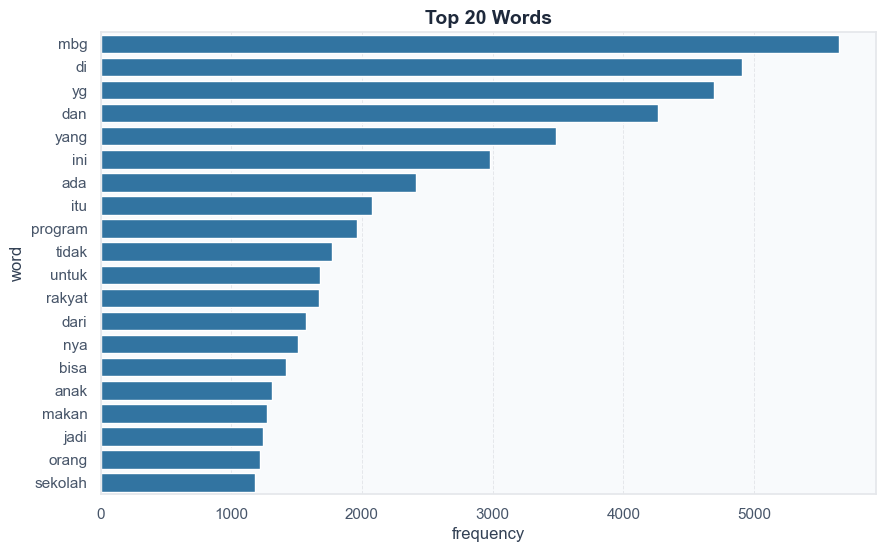

In [43]:
freq_df = word_frequency(df)
plt.figure(figsize=(10, 6))
sns.barplot(data=freq_df.head(20), x='frequency', y='word')
plt.title("Top 20 Words")
plt.show()
# isinya banyak banget stopwords dan kata gak bermakna
# nanti akan dibersihkan

## C. Data Preprocessing for Sentiment Analysis

In [44]:
# cek vocab
cek_vocab = CountVectorizer()
x_vocab = cek_vocab.fit_transform(df['Comment'])
vocab_sebelum = cek_vocab.get_feature_names_out()
print(len(vocab_sebelum))

22336


### C.1. Text Cleaning

In [45]:
import re

In [46]:
def text_cleaning(text):
    text = text.lower() # lowercase
    text = re.sub(r'[\n\r\t]', ' ', text) # delete newline atau tab
    text = re.sub(r'(.)\1+$', r'\1', text) # hapus karakter berulang di akhir kata
    text = text.replace("`", "'") # ganti petik, jadi petik yang biasa
    text = re.sub(r"'{2,}", "'", text)  # hapus petik berulang jadi satu
    text = re.sub(r"'\s|'\s*$|^\s*'", ' ', text)  # hapus petik di awal/akhir kata
    text = re.sub(r'http\S+|www\S+', '', text) # hapus jika ada URL
    text = re.sub(r'@\w+|#\w+', '', text) # hapus mention or hastag
    text = re.sub(r'\d+', '', text) # hapus angka
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) # hapus huruf banyak berulang
    text =re.sub(r"[^a-z\s']", ' ', text) # hapus karakter selain alfabet dan petik
    text = re.sub(r'\s+', ' ', text).strip() # rapihin spasi berlebih
    return text

In [47]:
df['cleaned_comment'] = df['Comment'].apply(text_cleaning)
df.head(5)

,Comment,length,word_count,cleaned_comment
0,Pemimpin yang gampang di bodohin😂😂😂,35,5,pemimpin yang gampang di bodohin
1,Kalau betul diberi dengan elok bantuan makanan...,806,107,kalau betul diberi dengan elok bantuan makanan...
2,Yo jelas kalau gak makan mati.APA KALAU GAK AD...,76,13,yo jelas kalau gak makan mati apa kalau gak ad...
3,MBG AJAKOK PROGRAM ANDALAN ORANGG NGARIT AJA B...,51,8,mbg ajakok program andalan orangg ngarit aja b...
4,Coba lihat fakta dilapangan,27,4,coba lihat fakta dilapangan


In [48]:
vocab_after_cleaning = cek_vocab.fit_transform(df['cleaned_comment'])
vocab_abis_cleaning = cek_vocab.get_feature_names_out()
print(len(vocab_abis_cleaning))

20449


## D. Sentiment Analysis using IndoBERT

### D.1. Import IndoBERT

In [49]:
from transformers import pipeline
sentiment_model = pipeline(
    "sentiment-analysis", 
    model="w11wo/indonesian-roberta-base-sentiment-classifier"
)

c:\Users\johan\Bina Nusantara\Semester 5\Deep Learning\Code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\johan\Bina Nusantara\Semester 5\Deep Learning\Code\venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Device set to use cpu


### D.2. Test

In [50]:
test_sentences = [
    "mantap banget",
    "jelek banget",
    "biasa aja sih",
    "MBG cepat dan ramah",
    "Stop MBG"
]

for text in test_sentences:
    print(text, "->", sentiment_model(text)[0])

mantap banget -> {'label': 'positive', 'score': 0.9992647767066956}
jelek banget -> {'label': 'negative', 'score': 0.9970645308494568}
biasa aja sih -> {'label': 'negative', 'score': 0.7566919922828674}
MBG cepat dan ramah -> {'label': 'positive', 'score': 0.9945005178451538}
Stop MBG -> {'label': 'negative', 'score': 0.9986477494239807}


### D.3. Classify Comments

In [51]:
from tqdm import tqdm

tqdm.pandas(desc="Classifying Sentiment")

def predict_sentiment(text):
    try:
        result = sentiment_model(str(text)[:1500])
        label = result[0]['label']
        score = result[0]['score']
        return pd.Series([label, score])
    except Exception as e:
        return pd.Series(["ERROR", 0.0])

df[['sentiment', 'confidence']] = df['cleaned_comment'].progress_apply(predict_sentiment)

print("Total data awal:", len(df))
print(df['sentiment'].value_counts())

df_clean = df[(df['sentiment'] != "ERROR") & (df['confidence'] > 0.90)].copy()

print("Total data setelah filter:", len(df_clean))
print(df_clean['sentiment'].value_counts())

df_clean[['cleaned_comment', 'sentiment', 'confidence']].head()

Classifying Sentiment: 100%|██████████| 13607/13607 [07:51<00:00, 28.84it/s]

Total data awal: 13607
sentiment
negative    8706
positive    2524
neutral     2363
ERROR         14
Name: count, dtype: int64
Total data setelah filter: 10679
sentiment
negative    7511
positive    1669
neutral     1499
Name: count, dtype: int64


,cleaned_comment,sentiment,confidence
0,pemimpin yang gampang di bodohin,negative,0.999448
1,kalau betul diberi dengan elok bantuan makanan...,negative,0.998362
2,yo jelas kalau gak makan mati apa kalau gak ad...,negative,0.997924
3,mbg ajakok program andalan orangg ngarit aja b...,negative,0.987616
5,dia tuli dan keras kepala gx mau dengar kompla...,negative,0.999414


In [52]:
df_clean.to_csv('./Data/data_youtube_comments_MBG_cleaned_sentiment.csv', index=False)